# Retail clients behaviour clustering

**Course:** Mathematical Foundations of Artificial Intelligence  
**University:** Jagiellonian University  
**Authors:** Patrycja Jaworska, Mateusz Paszyński
**Year:** 2025/2026

## Setup and Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## 1. Load and cleanse Data

In [3]:
import pandas as pd
import datetime as dt

df = pd.read_excel('data/Online Retail.xlsx')

df = df.dropna(subset=['CustomerID'])
df['CustomerID'] = df['CustomerID'].astype(int)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df = df[~df['InvoiceNo'].astype(str).str.contains('C')] #cancelled transactions

df['TotalPrice'] = df['Quantity'] * df['UnitPrice'].round(2)

now_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (now_date - x.max()).days, # Recency: days from last order
    'InvoiceNo': 'nunique',                             # Frequency: unique invoices
    'TotalPrice': 'sum'                                 # Monetary: sum
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

rfm['Monetary'] = rfm['Monetary'].round(2)

## 2. Finding optimal number of clusters using the elbow method

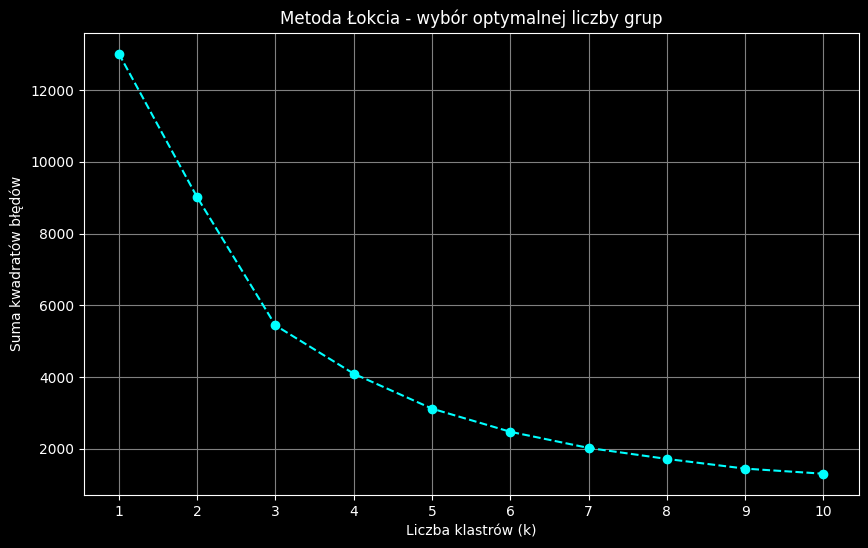

In [24]:
properties = rfm[['Recency','Frequency','Monetary']]
scaler = StandardScaler()
properties_scaled = scaler.fit_transform(properties)

SE = []
k_range = range(1,11)

for k in k_range :
    kmeans = KMeans(n_clusters=k, random_state=42,n_init=10)
    kmeans.fit(properties_scaled)
    SE.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, SE, marker='o', linestyle='--', color='cyan')
plt.xlabel('Liczba klastrów (k)')
plt.ylabel('Suma kwadratów błędów')
plt.title('Metoda Łokcia - wybór optymalnej liczby grup')
plt.grid(True,color='grey')
plt.xticks(k_range)
plt.show()


## 3. K-Means Clustering
From image above we choose 3 as our number of clusters

In [26]:
kmeans = KMeans(n_clusters=3,random_state=42,n_init=10)
clusters = kmeans.fit_transform(properties_scaled)

rfm['Cluster'] = kmeans.labels_
print(rfm.head())


   CustomerID  Recency  Frequency  Monetary  Cluster
0       12346      326          1  77183.60        0
1       12347        2          7   4310.00        1
2       12348       75          4   1797.24        1
3       12349       19          1   1757.55        1
4       12350      310          1    334.40        0


In [ ]:
%%sql


## 4. Visualization

In [7]:
pass

## 5. IoU Evaluation

In [8]:
pass

## 6. Analysis & Conclusions

In [9]:
pass